# Higer-Order Differential Equations and Systems of 1st-Order Differential Equations


In [1]:
# importing libraries
import numpy as np
import math
from matplotlib import pyplot as plt
from ipywidgets import interactive, fixed

# Definition of the IVP

In [2]:
# Define the IVP:

# Diff. Eqn.: y'' = f(x,y,y') = f(x,y0,y1)
def f(t, y):
    rhs = np.zeros((2, 1))
    # y[0] is y1, y[1] is y2
    rhs[0] = 3*y[0] + 2*y[1] - (2*t**2 + 1) * np.exp(2*t)
    rhs[1] = 4*y[0] + y[1] + (t**2 + 2*t - 4) * np.exp(2*t)
    return rhs

# Initial Condition
y0 = np.array([[-0.4],[-0.6]])

In [3]:
# Explicit Runge-Kutta 4th-order Method
def erk4(t, w, h):
    s1 = f(t, w)
    s2 = f(t + 0.5*h, w + 0.5*h*s1)
    s3 = f(t + 0.5*h, w + 0.5*h*s2)
    s4 = f(t + h, w + h*s3)

    phi = (1/6)*(s1 + 2*s2 + 2*s3 + s4)
    return phi

In [4]:
# Time-stepping method to solve Initial Value Problems (IVPs)
# Use with f(t,y) to evaluate rhs of differential equation
# Input: interval endoints a and b,
#        initial condition y0,
#        number of steps n,
#        time-stepping flag s,
#                           s = 1:  Euler
#                           s = 2:  Explicit Trapezoid Method
#                           s = 4:  Runge-Kutta 4th-order
#
# Output: time steps t, approximate solution w
# Usage: euler(a,b,y_0,n)
# Example: euler(0,1,1,10)
def tstep(a, b, y0, n, mthd):
    m = np.size(y0)
    t = np.zeros(n+1)
    w = np.zeros((m, n+1))
    h = (b-a)/n
    t[0] = a
    w[:, 0:1] = y0

    for i in range(1, n+1):
        t[i] = t[i-1] + h
        if mthd == 1: # Euler
            w[:, i:i+1] = w[:, i-1:i] + h * f(t[i-1], w[:, i-1:i])
        elif mthd == 2: # Explicit Trapezoid
            k1 = f(t[i-1], w[:, i-1:i])
            k2 = f(t[i], w[:, i-1:i] + h * k1)
            w[:, i:i+1] = w[:, i-1:i] + (h/2) * (k1 + k2)
        elif mthd == 4: # RK4
            w[:, i:i+1] = w[:, i-1:i] + h * erk4(t[i-1], w[:, i-1:i], h)
    return t, w


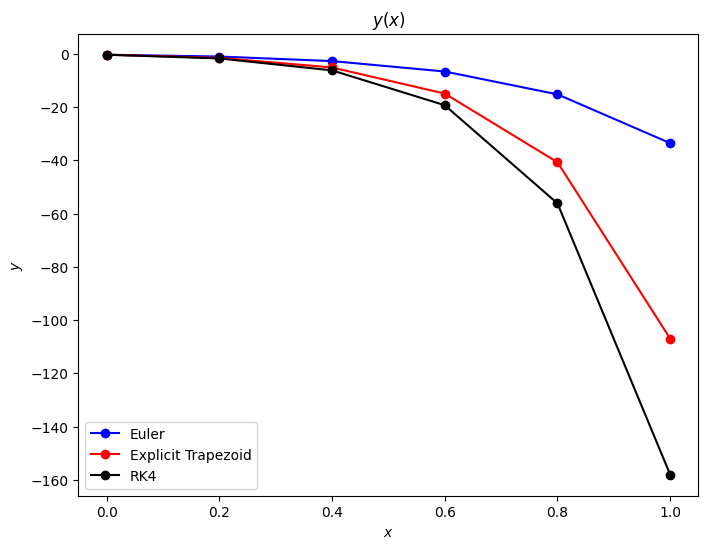

In [5]:
# Setup for Part (a)
a, b = 0, 1
h = 0.2
n = int((b-a)/h)
y0_a = np.array([[1.0], [1.0]]) # Initial conditions y1(0)=1, y2(0)=1

# Exact solution function for comparison
def exact_a(t):
    y1 = (1/3)*(np.exp(5*t) - np.exp(-t)) + np.exp(2*t)
    y2 = (1/3)*(np.exp(5*t) + 2*np.exp(-t)) + t**2 * np.exp(2*t)
    return y1, y2


[teu,weu]  = tstep(a,b,y0,n,1) # Euler
[ttr,wtr]  = tstep(a,b,y0,n,2) # Exp. Trap.
[trk,wrk]  = tstep(a,b,y0,n,4) # RK4

plt.figure(figsize=(8, 6))
plt.plot(teu,weu[0,:],'-o',color='blue',label = f'Euler')
plt.plot(ttr,wtr[0,:],'-o',color='red',label = f'Explicit Trapezoid')
plt.plot(trk,wrk[0,:],'-o',color='black',label = f'RK4')
plt.xlabel(f'$x$')
plt.ylabel(f'$y$')
plt.title(f'$y(x)$')

plt.legend();

In [7]:
import pandas as pd

# 1. Get exact values at the time steps
y1_ex, y2_ex = exact_a(teu) # All methods use same 't'

# 2. Calculate errors for each method
# Euler Errors
e1_eu = np.abs(y1_ex - weu[0, :])
e2_eu = np.abs(y2_ex - weu[1, :])

# Explicit Trapezoid Errors
e1_tr = np.abs(y1_ex - wtr[0, :])
e2_tr = np.abs(y2_ex - wtr[1, :])

# RK4 Errors
e1_rk = np.abs(y1_ex - wrk[0, :])
e2_rk = np.abs(y2_ex - wrk[1, :])

# 3. Create the Comparison Table
master_data = {
    'ti': teu,
    'y1_Exact': y1_ex,
    'Err1_Euler': e1_eu,
    'Err1_Trap': e1_tr,
    'Err1_RK4': e1_rk,
    'y2_Exact': y2_ex,
    'Err2_Euler': e2_eu,
    'Err2_Trap': e2_tr,
    'Err2_RK4': e2_rk
}

df_master = pd.DataFrame(master_data)
pd.options.display.float_format = '{:.6e}'.format # Scientific notation helps see small RK4 errors

print("Comparison of Global Truncation Error (Part a, h=0.2):")
print(df_master.to_string(index=True))

Comparison of Global Truncation Error (Part a, h=0.2):
            ti     y1_Exact   Err1_Euler    Err1_Trap     Err1_RK4     y2_Exact   Err2_Euler    Err2_Trap     Err2_RK4
0 0.000000e+00 1.000000e+00 1.400000e+00 1.400000e+00 1.400000e+00 1.000000e+00 1.600000e+00 1.600000e+00 1.600000e+00
1 2.000000e-01 2.125008e+00 3.205008e+00 3.718125e+00 3.922283e+00 1.511587e+00 3.351587e+00 3.878677e+00 4.085982e+00
2 4.000000e-01 4.465120e+00 7.251354e+00 9.645331e+00 1.073731e+01 3.265985e+00 7.400164e+00 9.759626e+00 1.087122e+01
3 6.000000e-01 9.832359e+00 1.653155e+01 2.483013e+01 2.919316e+01 8.256295e+00 1.679943e+01 2.487636e+01 2.930258e+01
4 8.000000e-01 2.300264e+01 3.828071e+01 6.377258e+01 7.920755e+01 2.166888e+01 3.890020e+01 6.370278e+01 7.929668e+01
5 1.000000e+00 5.673748e+01 9.033352e+01 1.637424e+02 2.147702e+02 5.710536e+01 9.174888e+01 1.634629e+02 2.148424e+02


# Boundary Value Problems (BVP)
## The Linear Shooting Method

In [ ]:
# Apporximation solution using RK4
# parameters specific to current BVP
a     =
b     =
n     =

# Boundary Conditions:
alpha =
beta  =

# Initial Condition
yp0 = np.array([[],[]])

# Solve Nonhomogenous problem
[t,wp]  = tstep(a,b,yp0,n,4)

In [ ]:
# Initial Condition
yh0 = np.array([[],[]])

# Solve homogeneous IVP
[t,wh] = tstep(a,b,yh0,n,4)

In [ ]:
# Form linear combination of nonhomogeneous and homogeneous solution
s = (beta - wp[0,-1])/wh[0,-1]

w = wp + s*wh

y_exact =


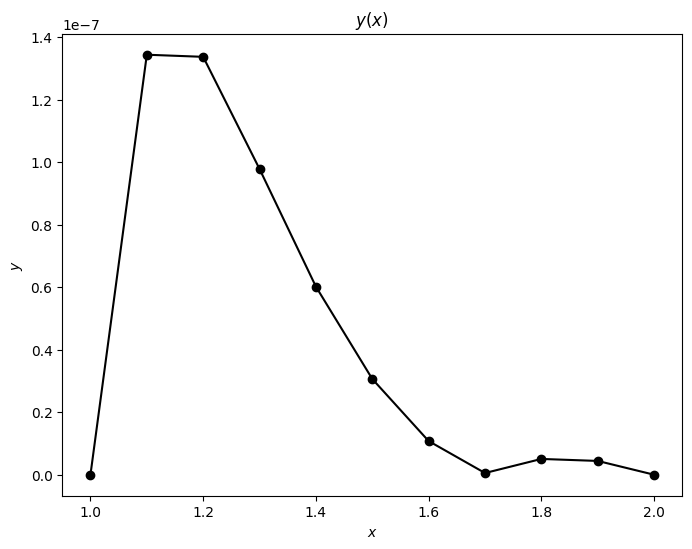

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(t,np.abs(y_exact - w[0,:]),'-o',color='black',label = f'RK4')
plt.xlabel(f'$x$')
plt.ylabel(f'$y$')
plt.title(f'$y(x)$');